In [8]:
from imports import *
%reload_ext autoreload
%autoreload 2

In [32]:
df = pd.read_excel('./dataset/oecd_dataset.xlsx', index_col='Reference area')
df = df[df.notnull().all(axis=1)]

In [153]:
df.round(1)

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Reference area,,,,,,,,,,,,
Australia,11860732.7,12063021.4,12455751.1,13723725.9,14701734.3,15461977.2,14738096.5,6112265.9,3984941.1,7525983.5,11298137.3,12870576.0
Austria,2032032.3,2138526.6,2219886.6,2289076.6,2294330.9,2556748.9,2966439.4,1041594.6,1240233.6,2078696.9,2469198.6,2682274.5
Belgium,3247814.2,3195722.8,3413040.5,3466534.3,3672222.0,3940235.8,4039798.5,2236333.8,3240717.6,3894086.3,3766052.1,3930514.0
Canada,9517376.7,10106189.4,10706255.2,11606782.6,12420954.4,13083421.6,13824361.0,5671979.1,5128085.8,9490621.0,11469309.5,12787228.3
Chile,1645285.3,1679696.5,1833572.8,1939507.5,2081471.4,2191711.5,2235390.1,1207357.4,1204832.9,1717065.8,1965011.6,2204970.0
...,...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,29525.4,26833.0,24494.2,22117.6,24196.7,28061.3,25512.0,5878.3,3157.2,11358.0,22313.9,11515.7
Venezuela,991198.7,715855.8,603853.4,573210.9,434663.1,400566.1,313361.9,74626.3,104650.5,193219.5,278163.1,245325.9
Viet Nam,2142564.9,2305220.9,2567449.5,3019055.6,3616451.4,4230438.4,4941541.3,1822487.4,1497054.1,2383585.2,4106124.5,3527683.0


In [33]:
df.shape

(183, 12)

* 결측을 제외한 183개를 대상으로 분석함

In [42]:
df_num = df.copy()
df_num = np.log(df_num[year_cols])

# 연도별 로그 성장률
growth = df_num.diff(axis=1).iloc[:, 1:]  # 2014~2024
display(growth)
print('''
연도별 로그 성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.
''')

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Reference area,,,,,,,,,,,
Australia,0.016912,0.032038,0.096944,0.068839,0.050418,-0.047948,-0.880138,-0.427775,0.635839,0.406276,0.130306
Austria,0.051081,0.037339,0.030692,0.002293,0.108295,0.148626,-1.046610,0.174547,0.516441,0.172152,0.082771
Belgium,-0.016169,0.065790,0.015552,0.057642,0.070444,0.024954,-0.591357,0.370957,0.183664,-0.033432,0.042743
Canada,0.060029,0.057680,0.080761,0.067795,0.051961,0.055086,-0.890894,-0.100806,0.615572,0.189371,0.108772
Chile,0.020699,0.087653,0.056168,0.070641,0.051608,0.019733,-0.615982,-0.002093,0.354276,0.134881,0.115216
...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,-0.095619,-0.091196,-0.102060,0.089843,0.148172,-0.095241,-1.467890,-0.621560,1.280222,0.675291,-0.661496
Venezuela,-0.325436,-0.170147,-0.052078,-0.276682,-0.081692,-0.245520,-1.434865,0.338132,0.613201,0.364381,-0.125620
Viet Nam,0.073173,0.107736,0.162031,0.180549,0.156812,0.155372,-0.997475,-0.196703,0.465106,0.543874,-0.151838



연도별 로그 성장률을 도출하였다.
2019년의 코로나 충격이 2020년 성장률에 영향을 미쳐 -1.46 로그 성장률이 도출된다.



In [54]:
# 전체 풀링 (NaN 제거)
all_growth = growth.values.flatten()

overall_mean = all_growth.mean()
overall_var  = all_growth.var(ddof=1)  # 표본분산
overall_std  = all_growth.std(ddof=1)

print(f'''전체 연도별 로그 성장률의 평균: {overall_mean:.5f}
전체 연도별 로그 성장률의 분산: {overall_var:.5f}
전체 연도별 로그 성장률의 표준편차: {overall_std:.5f}''')


전체 연도별 로그 성장률의 평균: 0.01598
전체 연도별 로그 성장률의 분산: 0.21149
전체 연도별 로그 성장률의 표준편차: 0.45988


In [80]:
country_means = growth.drop(columns=[2020]).mean(axis=1)
country_means.mean(), country_means.std(ddof=1)

(0.10792075367109275, 0.08199010593961072)

In [87]:
all_growth_wo_2020 = (
    # 격리
    growth.drop(columns=[2020, 2021, 2022, 2023])
    .values.flatten()
)
all_growth_wo_2020 = all_growth_wo_2020[~np.isnan(all_growth_wo_2020)]

print(f'''전체 연도별 로그 성장률 (2020년 제외)의 평균: {all_growth_wo_2020.mean():.5f}
전체 연도별 로그 성장률 (2020년 제외)의 분산: {all_growth_wo_2020.var(ddof=1):.5f}
전체 연도별 로그 성장률 (2020년 제외)의 표준편차: {all_growth_wo_2020.std(ddof=1):.5f}''')


전체 연도별 로그 성장률 (2020년 제외)의 평균: 0.03812
전체 연도별 로그 성장률 (2020년 제외)의 분산: 0.07066
전체 연도별 로그 성장률 (2020년 제외)의 표준편차: 0.26582


mean 0.015983465076052226 std 0.45988452886725434
skew -1.9976692684603798 kurtosis(excess) 38.128679047017414


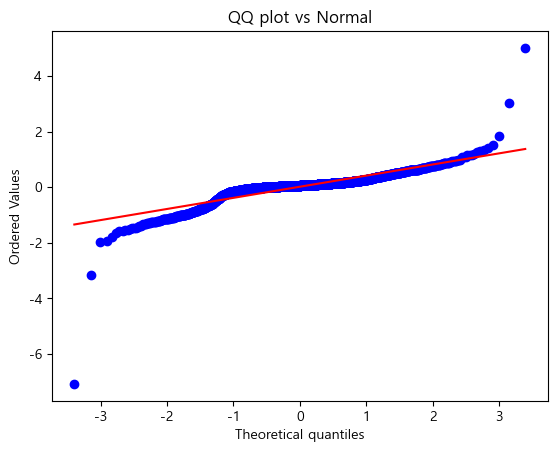

In [57]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

x = growth.values.flatten()
x = x[~np.isnan(x)]

print("mean", x.mean(), "std", x.std(ddof=1))
print("skew", stats.skew(x), "kurtosis(excess)", stats.kurtosis(x))  # excess=0이면 정규

# QQ plot (정규 기준)
stats.probplot(x, dist="norm", plot=plt)
plt.title("QQ plot vs Normal")
plt.show()


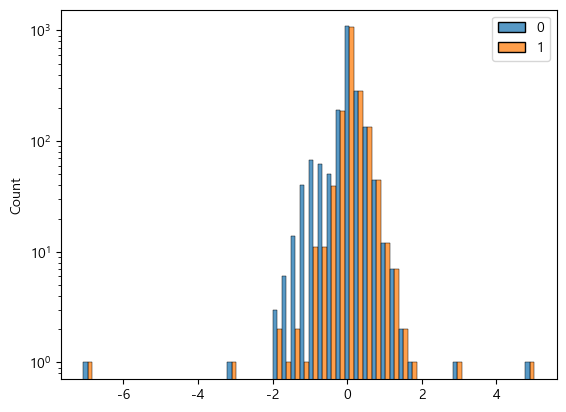

In [ ]:
sns.histplot([x,all_growth_wo_2020], bins=50, multiple='dodge')
plt.yscale('log')

In [94]:
x = growth.values.flatten()
summary = pd.DataFrame([{
    'Min': np.min(x),
    'Q1': np.percentile(x, 25),
    'Mean': np.mean(x),
    'Median': np.median(x),
    'Q3': np.percentile(x, 75),
    'Max': np.max(x),
    'Std': np.std(x, ddof=1)
}])
(summary*100).round(3)


,Min,Q1,Mean,Median,Q3,Max,Std
0,-708.132,-3.399,1.598,5.993,17.081,501.254,45.988


* 연구결과 첫번쨰 figure에 작성함  
* 성장률 데이터입니다.  
Min	Q1	Mean	Median	Q3	Max	Std  
0	-7.081323	-0.033992	0.015983	0.059929	0.170811	5.012535	0.459885  

In [105]:
x2019 = pd.to_numeric(df[2019], errors="coerce").dropna()

cap_2019_stats = pd.DataFrame([{
    "Baseline Year": 2019,
    "N": len(x2019),
    "Min": x2019.min(),
    "Q1": x2019.quantile(0.25),
    "Mean": x2019.mean(),
    "Median": x2019.median(),
    "Q3": x2019.quantile(0.75),
    "Max": x2019.max(),
    "Std. Dev.": x2019.std(ddof=1),
}])

cap_2019_stats.round(0)

,Baseline Year,N,Min,Q1,Mean,Median,Q3,Max,Std. Dev.
0,2019,183,3271.0,110435.0,3198154.0,409384.0,2158524.0,81575829.0,8362697.0


<Axes: xlabel='2019', ylabel='Count'>

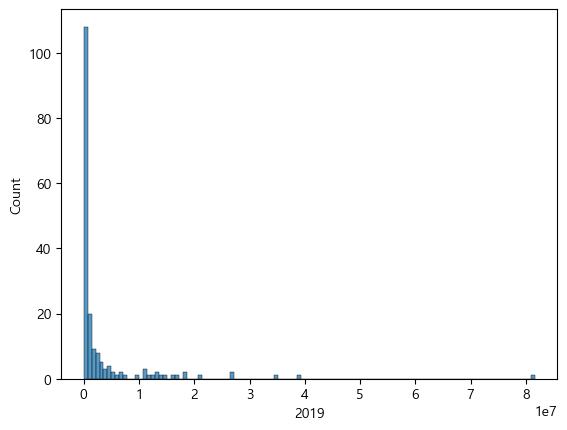

In [104]:
sns.histplot(df[2019])
# plt.xscale('log')

In [112]:
e_cap = df[2019].sum()
df.columns
for i in df.columns:
    print(f'{i}년: {df[i].sum() - e_cap}')

2013년: -147297594.70523357
2014년: -124524479.10950053
2015년: -98200548.03145301
2016년: -73764711.60764265
2017년: -45924168.50533974
2018년: -18705410.644227862
2019년: 0.0
2020년: -332711108.31636906
2021년: -312197328.7960069
2022년: -187219813.15386552
2023년: -93223182.03733599
2024년: -39227673.819178104


In [113]:
e_cap = df[2019]
df.columns
for i in df.columns:
    emission_offset = (df[i] - e_cap).clip(lower=0)
    print(f'{i}년: {emission_offset.sum()}')

2013년: 7956378.718986341
2014년: 8893371.302678265
2015년: 9334127.933080701
2016년: 11207080.606447073
2017년: 12913800.70333068
2018년: 15739436.766790904
2019년: 0.0
2020년: 36788.9955828251
2021년: 181454.04160164177
2022년: 1500065.6503684893
2023년: 6802136.674289644
2024년: 16375124.588879216


# 시뮬레이션

In [ ]:
# 성장률 통계
g_mean, g_std = summary['Mean'], summary['Std']
g_mean, g_std

(0    0.015983
 Name: Mean, dtype: float64,
 0    0.459885
 Name: Std, dtype: float64)

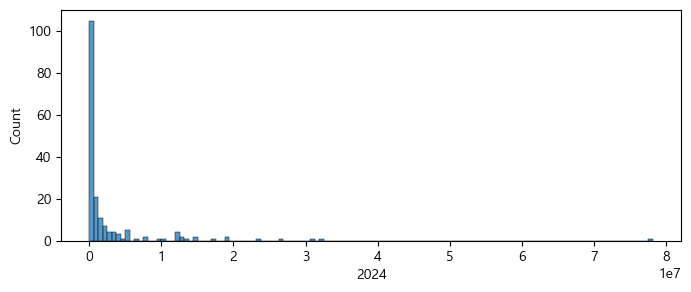

(<Figure size 800x300 with 1 Axes>,
 <Axes: xlabel='2024', ylabel='Count'>,
 None)

In [134]:
# 배출량 초기값, E_0 시점
e_0 = df[2024]
plt.figure(figsize=(8,3)), sns.histplot(e_0), plt.show()

In [141]:
# 시나리오 설정
random_seed = 42
np.random.seed(random_seed)
n = 10_000
start_year = 2024
end_year = 2050
years = end_year - start_year
n_country = len(df.index)

In [142]:
g_sim = np.random.normal(
    loc=g_mean,
    scale=g_std,
    size=(n, n_country, years)
)
g_sim.shape

(10000, 183, 26)

In [143]:
g_sim[:, :, 0]

array([[ 0.24441462, -0.51334067, -0.29532249, ..., -0.09038826,
         0.66301099, -0.46511144],
       [-0.29003395,  1.28306548,  0.36388076, ...,  0.39623376,
         0.26285292,  0.11225977],
       [ 0.86578891,  0.37614463,  1.0076553 , ...,  0.07933642,
         0.44047226,  0.24009125],
       ...,
       [-0.30731368,  0.51700207,  0.64412471, ...,  0.97897078,
         0.7665995 ,  0.24452306],
       [ 0.39063383, -0.68764138,  0.24042284, ..., -0.50140498,
        -0.115849  ,  0.20320375],
       [ 0.19288209,  0.29355524, -0.18216327, ..., -0.34861975,
        -0.42303639,  0.92551286]])

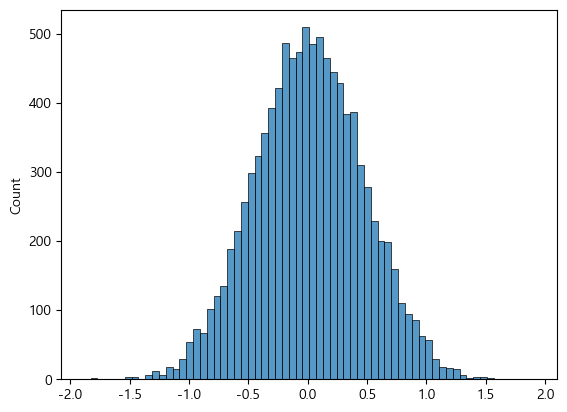

(<Axes: ylabel='Count'>, None)

In [159]:
sample = np.random.choice(g_sim.flatten(), size=10_000, replace=False)
sns.histplot(sample), plt.show()

In [155]:
# 누적 성장률
cumulative_growth = np.cumsum(g_sim, axis=2)
cumulative_growth.shape

(10000, 183, 26)

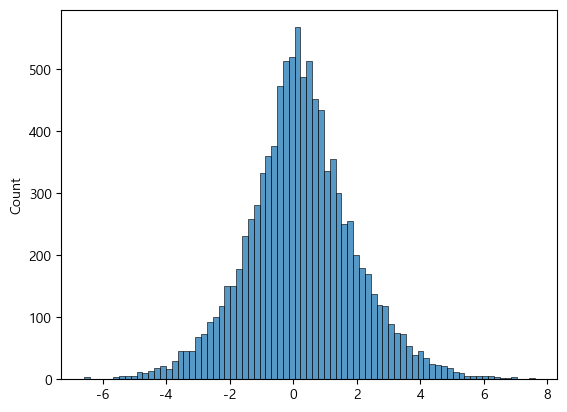

In [160]:
sample = np.random.choice(cumulative_growth.flatten(), size=10_000, replace=False)
sns.histplot(sample)
plt.show()

In [161]:
# 배출량
emissions = e_0.values[np.newaxis, :, np.newaxis] * np.exp(cumulative_growth)
emissions.shape

(10000, 183, 26)

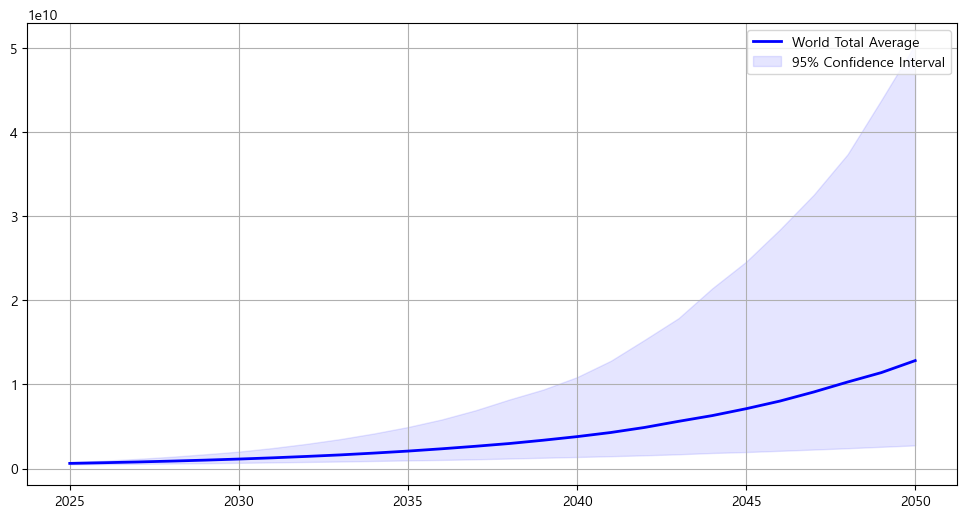

In [164]:
# 1. 모든 시나리오(s)와 국가(i)에 대해 연도별(t)로 합산 후 평균
# emissions shape: (10000, 193, 50)
# world_total_per_scenario: (10000, 50) -> 각 시나리오별 지구 전체 배출량
world_total_per_scenario = np.sum(emissions, axis=1)

# world_average_path: (50,) -> 10,000개 시나리오의 평균적인 지구 배출량 경로
world_average_path = np.mean(world_total_per_scenario, axis=0)

# world_average_path의 실제 길이에 맞춰 years_range를 생성합니다.
actual_years_count = world_average_path.shape[0]

# 초기 연도가 2025년이라면:
years_range = np.arange(2025, 2025 + actual_years_count)

# 이제 다시 그려보세요!
plt.figure(figsize=(12, 6))
plt.plot(years_range, world_average_path, color='blue', lw=2, label='World Total Average')

# 신뢰구간도 동일한 길이를 사용하게 됩니다.
upper_bound = np.percentile(world_total_per_scenario, 97.5, axis=0)
lower_bound = np.percentile(world_total_per_scenario, 2.5, axis=0)
plt.grid(True)
plt.fill_between(years_range, lower_bound, upper_bound, color='blue', alpha=0.1, label='95% Confidence Interval')
plt.legend()
plt.show()

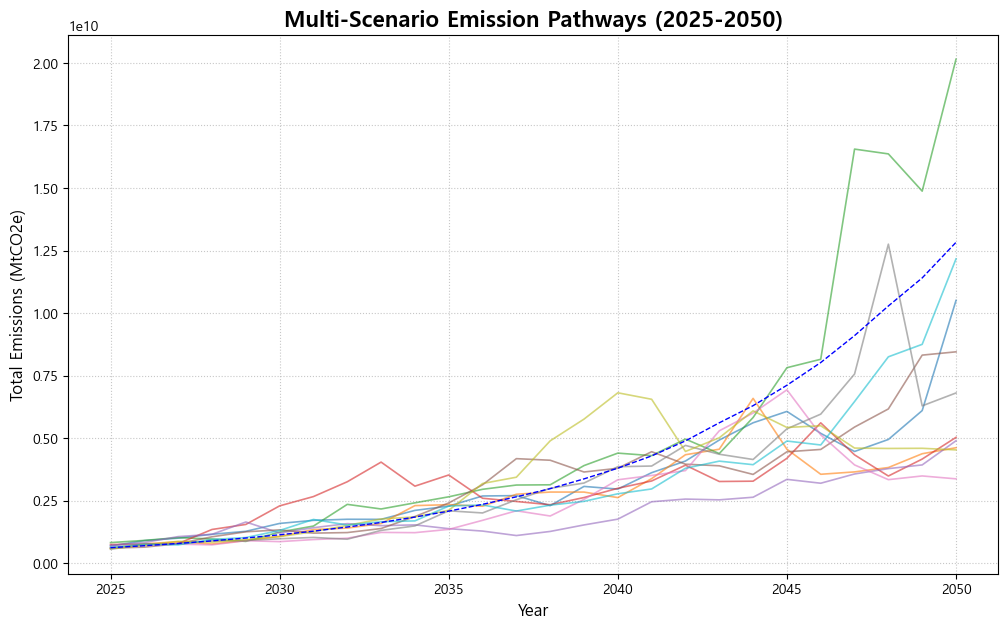

In [182]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 실제 데이터 길이에 맞게 연도 설정
actual_years_count = world_average_path.shape[0]
years_range = np.arange(2025, 2025 + actual_years_count)

plt.figure(figsize=(12, 7))

# 2. 개별 시나리오 n개 (다양한 색상으로 역동성 부여)
# 컬러맵을 사용하여 n개의 서로 다른 색상을 생성합니다.
n = 10
colors = plt.cm.tab10(np.linspace(0, 1, n)) 

for i in range(n):
    plt.plot(years_range, world_total_per_scenario[i, :actual_years_count], 
             lw=1.2, alpha=0.6, color=colors[i], 
             label=f'Scenario {i+1}')

# 3. 신뢰구간 (부드러운 연두색 계열로 배경 처리)
upper_bound = np.percentile(world_total_per_scenario, 97.5, axis=0)
lower_bound = np.percentile(world_total_per_scenario, 2.5, axis=0)

# plt.fill_between(years_range, lower_bound[:actual_years_count], upper_bound[:actual_years_count], 
#                  color='limegreen', alpha=0.15, label='95% Confidence Interval')

# 4. 전체 평균선 (가장 눈에 띄는 굵은 검정색 점선)
plt.plot(years_range, world_average_path, color='blue', lw=1, ls='--', label='World Average Trend')

# 그래프 꾸미기
plt.title('Multi-Scenario Emission Pathways (2025-2050)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Emissions (MtCO2e)', fontsize=12)

# 범례를 그래프 밖으로 빼서 시나리오 라벨이 겹치지 않게 합니다.
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)

# plt.tight_layout() # 범례가 잘리지 않도록 조정
plt.show()